### Loading Test Data and Pre-trained LSTM Model

This section will load the test dataset from a `.npz` file and a pre-trained LSTM model from a `.pth` file. You will need to replace the placeholder filenames with your actual file paths and ensure the `LSTMModel` class matches the architecture of your saved model.

In [2]:
import numpy as np
import torch
import torch.nn as nn

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
from scipy.special import expit

#### Load Test Data from `.npz`

Assuming your `.npz` file contains multiple arrays, you can load them as follows. If it only contains one array, you might directly access `data['array_name']` or `data[list(data.keys())[0]]`.

In [4]:
# Replace 'test_data.npz' with the actual path to your .npz file
try:
    loaded_data = np.load('test_dataset.npz')
    # List all arrays in the .npz file
    print(f"Arrays found in npz file: {list(loaded_data.keys())}")

    # Example: if your test features are stored under a key like 'X_test'
    # X_test = loaded_data['X_test']
    # y_test = loaded_data['y_test']
    # print(f"Loaded X_test shape: {X_test.shape}")
    # print(f"Loaded y_test shape: {y_test.shape}")

    # For demonstration, just print the keys and maybe the shape of the first array
    if len(loaded_data.keys()) > 0:
        first_key = list(loaded_data.keys())[0]
        print(f"First array '{first_key}' shape: {loaded_data[first_key].shape}")
    else:
        print("No arrays found in the .npz file.")

except FileNotFoundError:
    print("Error: 'test_dataset.npz' not found. Please provide the correct path.")
except Exception as e:
    print(f"An error occurred while loading the npz file: {e}")

Arrays found in npz file: ['song_id', 'time', 'valence', 'arousal', 'valence_std', 'arousal_std']
First array 'song_id' shape: (22756,)


#### Load Pre-trained LSTM Model from `.pth`

To load your PyTorch LSTM model, you first need to define the exact class structure of your model. The `state_dict` will then be loaded into an instance of this class. Please adjust the `LSTMModel` definition to match your original model's architecture (input size, hidden size, number of layers, etc.).

In [37]:
import torch.nn as nn

class ImprovedLSTMModel(nn.Module):

    def __init__(self, n_mels: int = 128, hidden_size: int = 256,
                 num_layers: int = 3, dropout: float = 0.4):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # BiLSTM - dwa directiony
        self.lstm = nn.LSTM(
            input_size=n_mels,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )

        # Multi-head attention (simplified - single head)
        self.attention_query = nn.Linear(hidden_size * 2, hidden_size)
        self.attention_key = nn.Linear(hidden_size * 2, hidden_size)
        self.attention_value = nn.Linear(hidden_size * 2, hidden_size)
        self.attention_scale = hidden_size ** 0.5

        # FC layers z dropout
        self.fc1 = nn.Linear(hidden_size, 512)
        self.dropout1 = nn.Dropout(dropout)

        self.fc2 = nn.Linear(512, 256)
        self.dropout2 = nn.Dropout(dropout)

        self.fc3 = nn.Linear(256, 128)
        self.dropout3 = nn.Dropout(dropout)

        # Output layer - 2 values (valence, arousal)
        self.output = nn.Linear(128, 2)

        self.relu = nn.ReLU()

    def forward(self, x):

        # Transpose dla LSTM: (batch, n_frames, n_mels)
        x = x.transpose(1, 2)

        # LSTM forward
        lstm_out, (h_n, c_n) = self.lstm(x)
        # lstm_out: (batch, n_frames, hidden_size*2)

        # Scaled dot-product attention
        Q = self.attention_query(lstm_out)  # (batch, n_frames, hidden_size)
        K = self.attention_key(lstm_out)
        V = self.attention_value(lstm_out)

        # Attention weights
        scores = torch.matmul(Q, K.transpose(1, 2)) / self.attention_scale
        # scores: (batch, n_frames, n_frames)

        attention_weights = torch.softmax(scores, dim=-1)
        # (batch, n_frames, n_frames)

        context = torch.matmul(attention_weights, V)
        # (batch, n_frames, hidden_size)

        # Pool: average over time
        context = context.mean(dim=1)

        # FC layers
        x = self.fc1(context)
        x = self.relu(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        x = self.relu(x)
        x = self.dropout3(x)

        x = self.output(x)

        return x

n_mels = 128
hidden_size = 128
num_layers = 2
dropout = 0.5

model = ImprovedLSTMModel(n_mels=n_mels, hidden_size=hidden_size, num_layers=num_layers, dropout=dropout)

try:
    checkpoint = torch.load('lstm_v2_best.pth')
    model.load_state_dict(checkpoint['model_state'])
    model.eval()
    print("LSTM model loaded successfully and set to evaluation mode.")
except Exception as e:
    print(f"An error occurred while loading the model: {e}")

LSTM model loaded successfully and set to evaluation mode.


In [6]:
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pickle

# Define the MelSpectrogramDataset class as provided in your original script
class MelSpectrogramDataset(Dataset):
    def __init__(self, mel_specs, valences, arousals):
        self.mel_specs = mel_specs  # List of numpy arrays/tensors
        self.valences = torch.tensor(valences, dtype=torch.float32)
        self.arousals = torch.tensor(arousals, dtype=torch.float32)

    def __len__(self):
        return len(self.mel_specs)

    def __getitem__(self, idx):
        # Convert mel_spec to tensor if it's not already
        mel_spec_tensor = torch.tensor(self.mel_specs[idx], dtype=torch.float32)
        return {
            'mel_spec': mel_spec_tensor,
            'valence': self.valences[idx],
            'arousal': self.arousals[idx]
        }

### Evaluation on Test Data

Now we will prepare the test data for evaluation, make predictions with the loaded model, and calculate the evaluation metrics.

In [36]:
# Load test mel spectrograms
try:
    with open('test_mel_specs.pkl', 'rb') as f:
        test_mel_specs = pickle.load(f)
    print(f"Loaded test_mel_specs.pkl with {len(test_mel_specs)} samples.")
except FileNotFoundError:
    print("Error: 'test_mel_specs.pkl' not found. Please ensure it's uploaded.")
    test_mel_specs = [] # Initialize as empty to prevent further errors
except Exception as e:
    print(f"An error occurred while loading test_mel_specs.pkl: {e}")

# Ensure loaded_data is available from the previous cell
if 'loaded_data' in locals() and len(test_mel_specs) > 0:
    # Assuming 'valence' and 'arousal' keys exist in loaded_data
    try:
        test_valences = loaded_data['valence']
        test_arousals = loaded_data['arousal']

        test_dataset = MelSpectrogramDataset(
            test_mel_specs,
            test_valences,
            test_arousals
        )

        # Create a DataLoader for the test set
        batch_size = 32 # You can adjust this batch size
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
        print(f"Test DataLoader created with {len(test_loader)} batches.")

        # Set device
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model.to(device)
        model.eval() # Ensure model is in evaluation mode

        all_pred = []
        all_target = []

        with torch.no_grad():
            for batch in test_loader:
                mel_specs = batch['mel_spec'].to(device)
                valences = batch['valence'].to(device)
                arousals = batch['arousal'].to(device)

                predictions = model(mel_specs)

                all_pred.append(predictions.cpu().numpy())
                all_target.append(torch.stack([valences, arousals], dim=1).cpu().numpy())

        all_pred = np.vstack(all_pred)
        all_target = np.vstack(all_target)

        # Compute and print metrics
        metrics = {
            'valence_mae': mean_absolute_error(all_target[:, 0], all_pred[:, 0]),
            'arousal_mae': mean_absolute_error(all_target[:, 1], all_pred[:, 1]),
            'valence_rmse': np.sqrt(mean_squared_error(all_target[:, 0], all_pred[:, 0])),
            'arousal_rmse': np.sqrt(mean_squared_error(all_target[:, 1], all_pred[:, 1])),
            'valence_corr': np.corrcoef(all_target[:, 0], all_pred[:, 0])[0, 1] if all_target.shape[0] > 1 else np.nan,
            'arousal_corr': np.corrcoef(all_target[:, 1], all_pred[:, 1])[0, 1] if all_target.shape[0] > 1 else np.nan,
        }

        print(f"\nTest Metrics:")
        print(f"  Valence: MAE={metrics['valence_mae']:.4f}, "
              f"RMSE={metrics['valence_rmse']:.4f}, "
              f"Corr={metrics['valence_corr']:.4f}")
        print(f"  Arousal: MAE={metrics['arousal_mae']:.4f}, "
              f"RMSE={metrics['arousal_rmse']:.4f}, "
              f"Corr={metrics['arousal_corr']:.4f}")

    except KeyError as ke:
        print(f"Error: Missing key in loaded_data: {ke}. Ensure 'valence' and 'arousal' are present.")
    except Exception as e:
        print(f"An error occurred during evaluation: {e}")
else:
    print("Skipping evaluation: test_mel_specs or loaded_data not available.")

Loaded test_mel_specs.pkl with 22756 samples.
Test DataLoader created with 712 batches.

Test Metrics:
  Valence: MAE=0.1457, RMSE=0.1856, Corr=0.4762
  Arousal: MAE=0.1867, RMSE=0.2338, Corr=0.6620


### Visualizing Example Mel Spectrograms

Let's visualize a couple of mel spectrograms from the test dataset to get a better understanding of the input data the model receives.

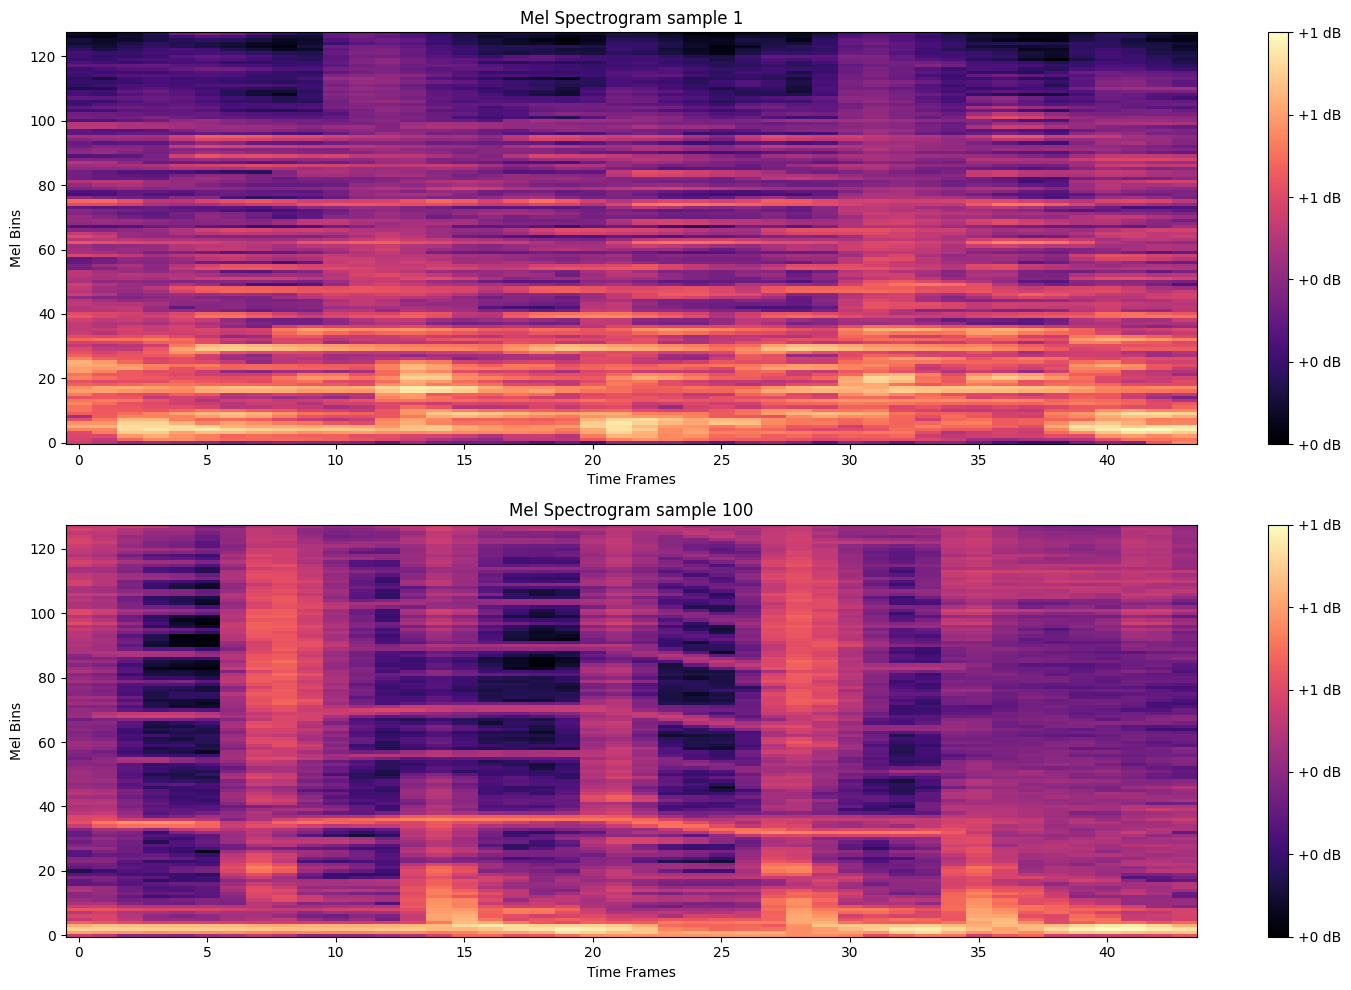

In [8]:
import matplotlib.pyplot as plt

# Check if test_mel_specs is available and not empty
if 'test_mel_specs' in locals() and len(test_mel_specs) > 1:
    # Select the first two mel spectrograms
    mel_spec_1 = test_mel_specs[0]
    mel_spec_2 = test_mel_specs[100]

    fig, axes = plt.subplots(2, 1, figsize=(15, 10))

    # Plot first mel spectrogram
    im1 = axes[0].imshow(mel_spec_1, origin='lower', aspect='auto', cmap='magma')
    axes[0].set_title('Mel Spectrogram sample 1')
    axes[0].set_xlabel('Time Frames')
    axes[0].set_ylabel('Mel Bins')
    fig.colorbar(im1, ax=axes[0], format='%+2.0f dB')

    # Plot second mel spectrogram
    im2 = axes[1].imshow(mel_spec_2, origin='lower', aspect='auto', cmap='magma')
    axes[1].set_title('Mel Spectrogram sample 100')
    axes[1].set_xlabel('Time Frames')
    axes[1].set_ylabel('Mel Bins')
    fig.colorbar(im2, ax=axes[1], format='%+2.0f dB')

    plt.tight_layout()
    plt.show()
else:
    print("Cannot visualize mel spectrograms: 'test_mel_specs' not available or contains too few samples.")

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from typing import Tuple, List, Dict
import json

class EmotionTagger:

    def __init__(self, thresholds=None):
        if thresholds is None:
            thresholds = {
                'valence_threshold': 0.2,
                'arousal_threshold': 0.5,
                'neutral_radius': 0.05
            }

        self.thresholds = thresholds

        # 5 emotions (4 quadranty + neutral)
        self.emotion_labels = ['NEUTRAL', 'HAPPY', 'CALM', 'ANGRY', 'SAD']

        # Mapping dla każdej emocji
        self.emotion_colors = {
            'NEUTRAL': '#808080',  # Gray
            'HAPPY': '#FFD700',    # Gold
            'CALM': '#87CEEB',     # Sky blue
            'ANGRY': '#FF6347',    # Tomato red
            'SAD': '#4169E1'       # Royal blue
        }

    def tag_emotion(self, valence: float, arousal: float) -> str:

        # Normalize do [0, 1] jeśli trzeba
        if valence < 0:
            valence = (valence + 1) / 2
        if arousal < 0:
            arousal = (arousal + 1) / 2

        v_thresh = self.thresholds['valence_threshold']
        a_thresh = self.thresholds['arousal_threshold']
        neutral_r = self.thresholds['neutral_radius']

        # Sprawdzenie neutral zone (distance from center < radius)
        dist_from_center = np.sqrt((valence - 0.5)**2 + (arousal - 0.5)**2)
        if dist_from_center < neutral_r:
            return 'NEUTRAL'

        # Quadrant classification
        high_valence = valence > v_thresh
        high_arousal = arousal > a_thresh

        if high_valence and high_arousal:
            return 'HAPPY'        # Positive + Active
        elif high_valence and not high_arousal:
            return 'CALM'         # Positive + Passive
        elif not high_valence and high_arousal:
            return 'ANGRY'        # Negative + Active
        else:
            return 'SAD'          # Negative + Passive

    def tag_batch(self, valences: np.ndarray, arousals: np.ndarray) -> np.ndarray:
        emotions = np.array([
            self.tag_emotion(v, a)
            for v, a in zip(valences, arousals)
        ])
        return emotions

    def emotion_to_label_id(self, emotion: str) -> int:
        """Convert emotion string → numeric ID."""
        return self.emotion_labels.index(emotion)

    def label_id_to_emotion(self, label_id: int) -> str:
        """Convert numeric ID → emotion string."""
        return self.emotion_labels[label_id]

class EmotionEvaluator:

    def __init__(self, tagger: EmotionTagger = None):
        self.tagger = tagger if tagger else EmotionTagger()

    def evaluate(self,
                 true_valences: np.ndarray,
                 true_arousals: np.ndarray,
                 pred_valences: np.ndarray,
                 pred_arousals: np.ndarray) -> Dict:

        # Tag emotions
        true_emotions = self.tagger.tag_batch(true_valences, true_arousals)
        pred_emotions = self.tagger.tag_batch(pred_valences, pred_arousals)

        # Convert to numeric IDs dla metryk
        true_ids = np.array([self.tagger.emotion_to_label_id(e) for e in true_emotions])
        pred_ids = np.array([self.tagger.emotion_to_label_id(e) for e in pred_emotions])

        # Metrics
        accuracy = accuracy_score(true_ids, pred_ids)

        # Per-emotion accuracy
        per_emotion_acc = {}
        for emotion in self.tagger.emotion_labels:
            emotion_mask = true_emotions == emotion
            if emotion_mask.sum() > 0:
                emotion_acc = accuracy_score(
                    true_ids[emotion_mask],
                    pred_ids[emotion_mask]
                )
                per_emotion_acc[emotion] = emotion_acc

        # Confusion matrix
        cm = confusion_matrix(true_ids, pred_ids,
                             labels=range(len(self.tagger.emotion_labels)))

        # Classification report
        class_report = classification_report(
            true_ids, pred_ids,
            target_names=self.tagger.emotion_labels,
            labels=range(len(self.tagger.emotion_labels)), # <--- ADDED THIS LINE
            output_dict=True,
            zero_division=0
        )

        # Distribution stats
        dist_true = {
            emotion: (true_emotions == emotion).sum()
            for emotion in self.tagger.emotion_labels
        }
        dist_pred = {
            emotion: (pred_emotions == emotion).sum()
            for emotion in self.tagger.emotion_labels
        }

        results = {
            'overall_accuracy': float(accuracy),
            'per_emotion_accuracy': {k: float(v) for k, v in per_emotion_acc.items()},
            'confusion_matrix': cm.tolist(),
            'classification_report': class_report,
            'true_distribution': dist_true,
            'pred_distribution': dist_pred,
            'true_emotions': true_emotions.tolist(),
            'pred_emotions': pred_emotions.tolist(),
            'true_ids': true_ids.tolist(),
            'pred_ids': pred_ids.tolist()
        }

        return results

    def plot_confusion_matrix(self, results: Dict, save_path='emotion_confusion_matrix.png'):
        """Plot confusion matrix."""
        cm = np.array(results['confusion_matrix'])

        fig, ax = plt.subplots(figsize=(10, 8))

        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=self.tagger.emotion_labels,
            yticklabels=self.tagger.emotion_labels,
            ax=ax,
            cbar_kws={'label': 'Count'}
        )

        ax.set_xlabel('Predicted Emotion')
        ax.set_ylabel('True Emotion')
        ax.set_title(f"Emotion Classification Confusion Matrix\n"
                    f"Accuracy: {results['overall_accuracy']:.1%}")

        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved confusion matrix: {save_path}")
        plt.close()

    def plot_distributions(self, results: Dict, save_path='emotion_distributions.png'):
        """Plot true vs predicted emotion distributions."""
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        emotions = self.tagger.emotion_labels
        true_counts = [results['true_distribution'][e] for e in emotions]
        pred_counts = [results['pred_distribution'][e] for e in emotions]

        x = np.arange(len(emotions))
        width = 0.35

        # True distribution
        axes[0].bar(x - width/2, true_counts, width, label='True', alpha=0.8)
        axes[0].bar(x + width/2, pred_counts, width, label='Predicted', alpha=0.8)
        axes[0].set_xlabel('Emotion')
        axes[0].set_ylabel('Count')
        axes[0].set_title('True vs Predicted Emotion Distribution')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(emotions)
        axes[0].legend()
        axes[0].grid(alpha=0.3)

        # Per-emotion accuracy
        per_emotion_acc = results['per_emotion_accuracy']
        accs = [per_emotion_acc.get(e, 0) for e in emotions]
        colors = [self.tagger.emotion_colors.get(e, '#808080') for e in emotions]

        axes[1].bar(emotions, accs, color=colors, alpha=0.7)
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Per-Emotion Classification Accuracy')
        axes[1].set_ylim([0, 1])
        axes[1].grid(alpha=0.3, axis='y')

        # Add percentage labels on bars
        for i, (emotion, acc) in enumerate(zip(emotions, accs)):
            axes[1].text(i, acc + 0.02, f'{acc:.0%}', ha='center', va='bottom')

        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved distributions: {save_path}")
        plt.close()

    def plot_valence_arousal_scatter(self,
                                     true_valences: np.ndarray,
                                     true_arousals: np.ndarray,
                                     pred_valences: np.ndarray,
                                     pred_arousals: np.ndarray,
                                     save_path='emotion_scatter.png'):
        # """Plot valence-arousal space z emotion quadrants."""
        # fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # tagger = self.tagger

        # # True emotions scatter
        # ax = axes[0]
        # true_emotions = tagger.tag_batch(true_valences, true_arousals)

        # for emotion in tagger.emotion_labels:
        #     mask = true_emotions == emotion
        #     ax.scatter(
        #         true_valences[mask], true_arousals[mask],
        #         label=emotion,
        #         color=tagger.emotion_colors[emotion],
        #         alpha=0.6,
        #         s=50,
        #         edgecolors='black',
        #         linewidth=0.5
        #     )

        # # Draw quadrant lines
        # ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
        # ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)

        # # Draw neutral circle
        # from matplotlib.patches import Circle
        # neutral_r = tagger.thresholds['neutral_radius']
        # circle = Circle((0.5, 0.5), neutral_r, fill=False,
        #                linestyle='--', color='gray', alpha=0.5)
        # ax.add_patch(circle)

        # ax.set_xlabel('Valence')
        # ax.set_ylabel('Arousal')
        # ax.set_title('True Emotions (Valence-Arousal Space)')
        # ax.set_xlim([-0.05, 1.05])
        # ax.set_ylim([-0.05, 1.05])
        # ax.legend()
        # ax.grid(alpha=0.3)

        # # Predicted emotions scatter
        # ax = axes[1]
        # pred_emotions = tagger.tag_batch(pred_valences, pred_arousals)

        # for emotion in tagger.emotion_labels:
        #     mask = pred_emotions == emotion
        #     ax.scatter(
        #         pred_valences[mask], pred_arousals[mask],
        #         label=emotion,
        #         color=tagger.emotion_colors[emotion],
        #         alpha=0.6,
        #         s=50,
        #         edgecolors='black',
        #         linewidth=0.5
        #     )

        # # Draw quadrant lines
        # ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
        # ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)

        # # Draw neutral circle
        # circle = Circle((0.5, 0.5), neutral_r, fill=False,
        #                linestyle='--', color='gray', alpha=0.5)
        # ax.add_patch(circle)

        # ax.set_xlabel('Valence')
        # ax.set_ylabel('Arousal')
        # ax.set_title('Predicted Emotions (Valence-Arousal Space)')
        # ax.set_xlim([-0.05, 1.05])
        # ax.set_ylim([-0.05, 1.05])
        # ax.legend()
        # ax.grid(alpha=0.3)

        # plt.tight_layout()
        # plt.savefig(save_path, dpi=150, bbox_inches='tight')
        # print(f"✓ Saved scatter plot: {save_path}")
        # plt.close()

        ax = axes[0]
        true_emotions = tagger.tag_batch(true_valences, true_arousals)

        for emotion in tagger.emotion_labels:
            mask = true_emotions == emotion
            ax.scatter(
                true_valences[mask],
                true_arousals[mask],
                label=emotion,
                color=tagger.emotion_colors[emotion],
                alpha=0.6,
                s=50,
                edgecolors='black',
                linewidth=0.5
            )

        # Linie podziału dla zakresu [-1,1]
        ax.axvline(x=0.0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
        ax.axhline(y=0.0, color='gray', linestyle='--', alpha=0.5, linewidth=1)

        # Neutral zone wokół środka (0,0)
        from matplotlib.patches import Circle
        neutral_r = tagger.thresholds['neutral_radius']
        circle = Circle((0.0, 0.0), neutral_r, fill=False,
                        linestyle='--', color='gray', alpha=0.5)
        ax.add_patch(circle)

        ax.set_xlabel('Valence')
        ax.set_ylabel('Arousal')
        ax.set_title('True Emotions (Valence-Arousal Space)')
        ax.set_xlim([-1.05, 1.05])
        ax.set_ylim([-1.05, 1.05])
        ax.legend()
        ax.grid(alpha=0.3)

In [12]:
import numpy as np
import pickle
import torch
# The EmotionTagger and EmotionEvaluator classes are defined in cell AxHAfkYDJ6sJ, so no need to import them from a file.
import json

def evaluate_lstm_emotions(
    model,
    test_mel_specs,
    true_valences,
    true_arousals,
    output_file='lstm_emotion_results.json'
):
    """
    Ewaluuje klasyfikację emocji na zbiorze testowym za pomocą modelu LSTM.

    Args:
        model: Załadowany model LSTM (ImprovedLSTMModel).
        test_mel_specs: Lista mel spektrogramów dla danych testowych.
        true_valences: Rzeczywiste wartości walencji dla danych testowych.
        true_arousals: Rzeczywiste wartości wzbudzenia dla danych testowych.
        output_file: Plik, do którego mają zostać zapisane wyniki.
    """

    print("="*70)
    print("LSTM EMOTION CLASSIFICATION EVALUATION")
    print("="*70 + "\n")

    print(f"✓ Loaded {len(true_valences)} test samples\n")

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device) # Ensure model is on the correct device
    model.eval() # Set model to evaluation mode

    print("Making predictions...")
    pred_valences = []
    pred_arousals = []

    with torch.no_grad():
        for i, mel_spec in enumerate(test_mel_specs):
            if (i + 1) % 5000 == 0:
                print(f"  {i + 1}/{len(test_mel_specs)}")

            # Prepare input
            x = torch.FloatTensor(mel_spec).unsqueeze(0).to(device)
            # x shape: (1, n_mels, n_frames)

            # Predict
            output = model(x)
            # output shape: (1, 2)

            pred_valences.append(output[0, 0].cpu().numpy())
            pred_arousals.append(output[0, 1].cpu().numpy())

    pred_valences = np.array(pred_valences)
    pred_arousals = np.array(pred_arousals)

    # Clip to [0, 1]
    # pred_valences = np.clip(pred_valences, 0, 1)
    # pred_arousals = np.clip(pred_arousals, 0, 1)

    pred_valences = expit(pred_valences)  # Sigmoid: (-∞, +∞) → (0, 1)
    pred_valences = np.clip(pred_valences, 0, 1)

    pred_arousals = expit(pred_arousals)  # Sigmoid: (-∞, +∞) → (0, 1)
    pred_arousals = np.clip(pred_arousals, 0, 1)

    print(f"✓ Predictions made\n")

    # Evaluate emotions
    print("Evaluating emotion classification...")
    tagger = EmotionTagger()
    evaluator = EmotionEvaluator(tagger)

    results = evaluator.evaluate(true_valences, true_arousals,
                                  pred_valences, pred_arousals)

    print(f"\n{'='*70}")
    print("RESULTS")
    print(f"{'='*70}\n")

    print(f"✓ Overall Emotion Classification Accuracy: {results['overall_accuracy']:.1%}\n")

    print("Per-Emotion Accuracy:")
    for emotion in tagger.emotion_labels:
        acc = results['per_emotion_accuracy'].get(emotion, 0)
        count = results['true_distribution'][emotion]
        print(f"  {emotion:10s}: {acc:6.1%} (n={count:5d})")

    print("\nTrue Emotion Distribution:")
    for emotion in tagger.emotion_labels:
        count = results['true_distribution'][emotion]
        pct = count / len(true_valences) * 100
        print(f"  {emotion:10s}: {count:5d} ({pct:5.1f}%)")

    print("\nPredicted Emotion Distribution:")
    for emotion in tagger.emotion_labels:
        count = results['pred_distribution'][emotion]
        pct = count / len(pred_valences) * 100
        print(f"  {emotion:10s}: {count:5d} ({pct:5.1f}%)")

    # Regression metrics (valence & arousal separately)
    from sklearn.metrics import mean_absolute_error, mean_squared_error

    print(f"\n{'='*70}")
    print("REGRESSION METRICS (Valence & Arousal)")
    print(f"{'='*70}\n")

    mae_val = mean_absolute_error(true_valences, pred_valences)
    mae_arou = mean_absolute_error(true_arousals, pred_arousals)
    rmse_val = np.sqrt(mean_squared_error(true_valences, pred_valences))
    rmse_arou = np.sqrt(mean_squared_error(true_arousals, pred_arousals))

    print(f"Valence:")
    print(f"  MAE:  {mae_val:.4f}")
    print(f"  RMSE: {rmse_val:.4f}")

    print(f"\nArousal:")
    print(f"  MAE:  {mae_arou:.4f}")
    print(f"  RMSE: {rmse_arou:.4f}")

    # Save results
    print(f"\n{'='*70}")
    print("SAVING RESULTS")
    print(f"{'='*70}\n")

    full_results = {
        **results,
        'regression_metrics': {
            'valence_mae': float(mae_val),
            'valence_rmse': float(rmse_val),
            'arousal_mae': float(mae_arou),
            'arousal_rmse': float(rmse_arou)
        }
    }

    # with open(output_file, 'w') as f:
    #     json.dump(full_results, f, indent=2)

    # print(f"✓ Saved results to: {output_file}")

    # Plot results (assuming evaluator methods are available)
    evaluator.plot_confusion_matrix(results, 'emotion_cm_lstm.png')
    evaluator.plot_distributions(results, 'emotion_dist_lstm.png')
    evaluator.plot_valence_arousal_scatter(
        true_valences, true_arousals,
        pred_valences, pred_arousals,
        'emotion_scatter_lstm.png'
    )

    print("\n✓ All plots saved!")

    return results

def compare_models(models_to_test):
    # This function is not used in the current context but kept for completeness
    # if it were to be used for comparing multiple models. It would also need refactoring
    # to accept pre-loaded data/models if it were to be called directly.
    print("\n\n" + "="*70)
    print("COMPARING MULTIPLE MODELS")
    print("="*70 + "\n")

    comparison_results = {}

    for model_name, (model_obj, mel_specs, valences, arousals) in models_to_test.items():
        print(f"\nEvaluating: {model_name}")

        try:
            results = evaluate_lstm_emotions(
                model=model_obj,
                test_mel_specs=mel_specs,
                true_valences=valences,
                true_arousals=arousals,
                output_file=f'{model_name}_emotion_results.json'
            )

            comparison_results[model_name] = {
                'overall_accuracy': results['overall_accuracy'],
                'per_emotion_accuracy': results['per_emotion_accuracy']
            }
        except Exception as e:
            print(f"✗ Error: {e}")
            comparison_results[model_name] = {'error': str(e)}

    # Print comparison table
    print("\n\n" + "="*70)
    print("MODEL COMPARISON")
    print("="*70 + "\n")

    print(f"{'Model':<30} {'Overall Acc':>15}")
    print("-" * 47)

    for model_name, res in comparison_results.items():
        if 'error' not in res:
            acc = res['overall_accuracy']
            print(f"{model_name:<30} {acc:>14.1%}")
        else:
            print(f"{model_name:<30} {'ERROR':>15}")

In [13]:
results = evaluate_lstm_emotions(
    model=model,
    test_mel_specs=test_mel_specs,
    true_valences=test_valences,
    true_arousals=test_arousals,
    output_file='lstm_emotion_results.json'
)

LSTM EMOTION CLASSIFICATION EVALUATION

✓ Loaded 22756 test samples

Making predictions...
  5000/22756
  10000/22756
  15000/22756
  20000/22756
✓ Predictions made

Evaluating emotion classification...

RESULTS

✓ Overall Emotion Classification Accuracy: 13.6%

Per-Emotion Accuracy:
  NEUTRAL   :  40.5% (n=  744)
  HAPPY     :   0.0% (n=    0)
  CALM      :  57.9% (n=  242)
  ANGRY     :   2.3% (n= 1369)
  SAD       :  12.9% (n=20401)

True Emotion Distribution:
  NEUTRAL   :   744 (  3.3%)
  HAPPY     :     0 (  0.0%)
  CALM      :   242 (  1.1%)
  ANGRY     :  1369 (  6.0%)
  SAD       : 20401 ( 89.7%)

Predicted Emotion Distribution:
  NEUTRAL   :  8854 ( 38.9%)
  HAPPY     :  5564 ( 24.5%)
  CALM      :  5321 ( 23.4%)
  ANGRY     :   274 (  1.2%)
  SAD       :  2743 ( 12.1%)

REGRESSION METRICS (Valence & Arousal)

Valence:
  MAE:  0.4567
  RMSE: 0.4973

Arousal:
  MAE:  0.5350
  RMSE: 0.5997

SAVING RESULTS

✓ Saved confusion matrix: emotion_cm_lstm.png
✓ Saved distributions: emo

Displaying Emotion Classification Confusion Matrix:


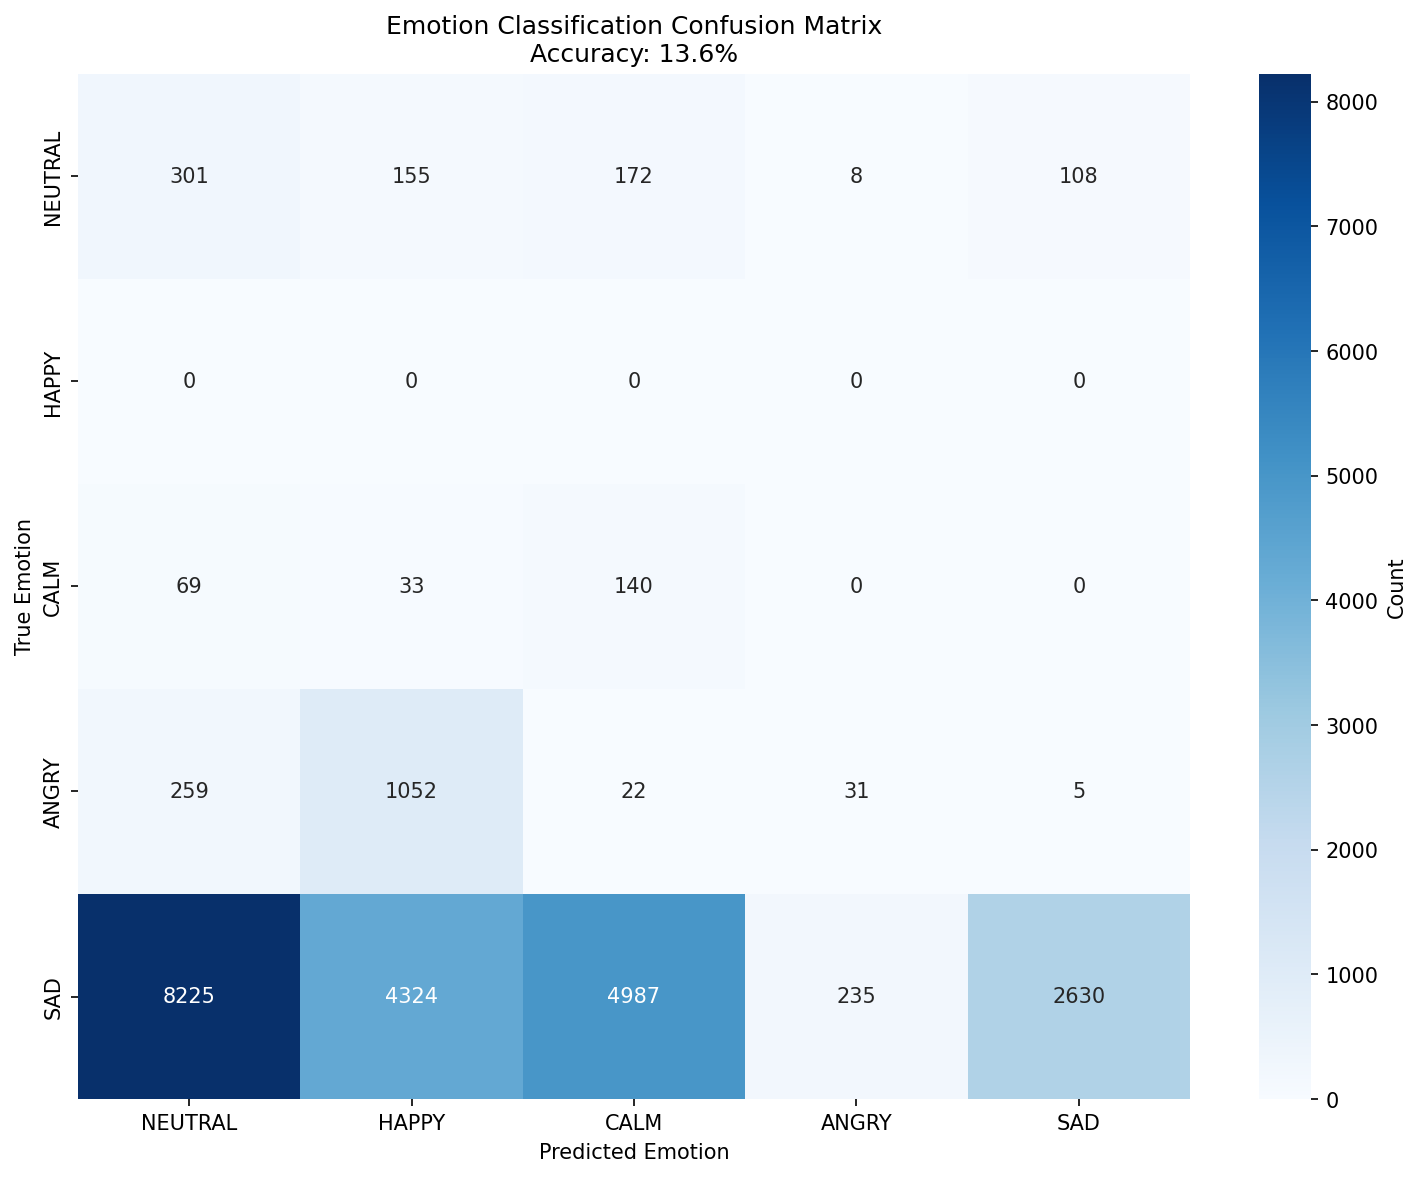

In [15]:
from IPython.display import Image, display

print("Displaying Emotion Classification Confusion Matrix:")
display(Image(filename='emotion_cm_lstm.png'))


Displaying True vs Predicted Emotion Distributions:


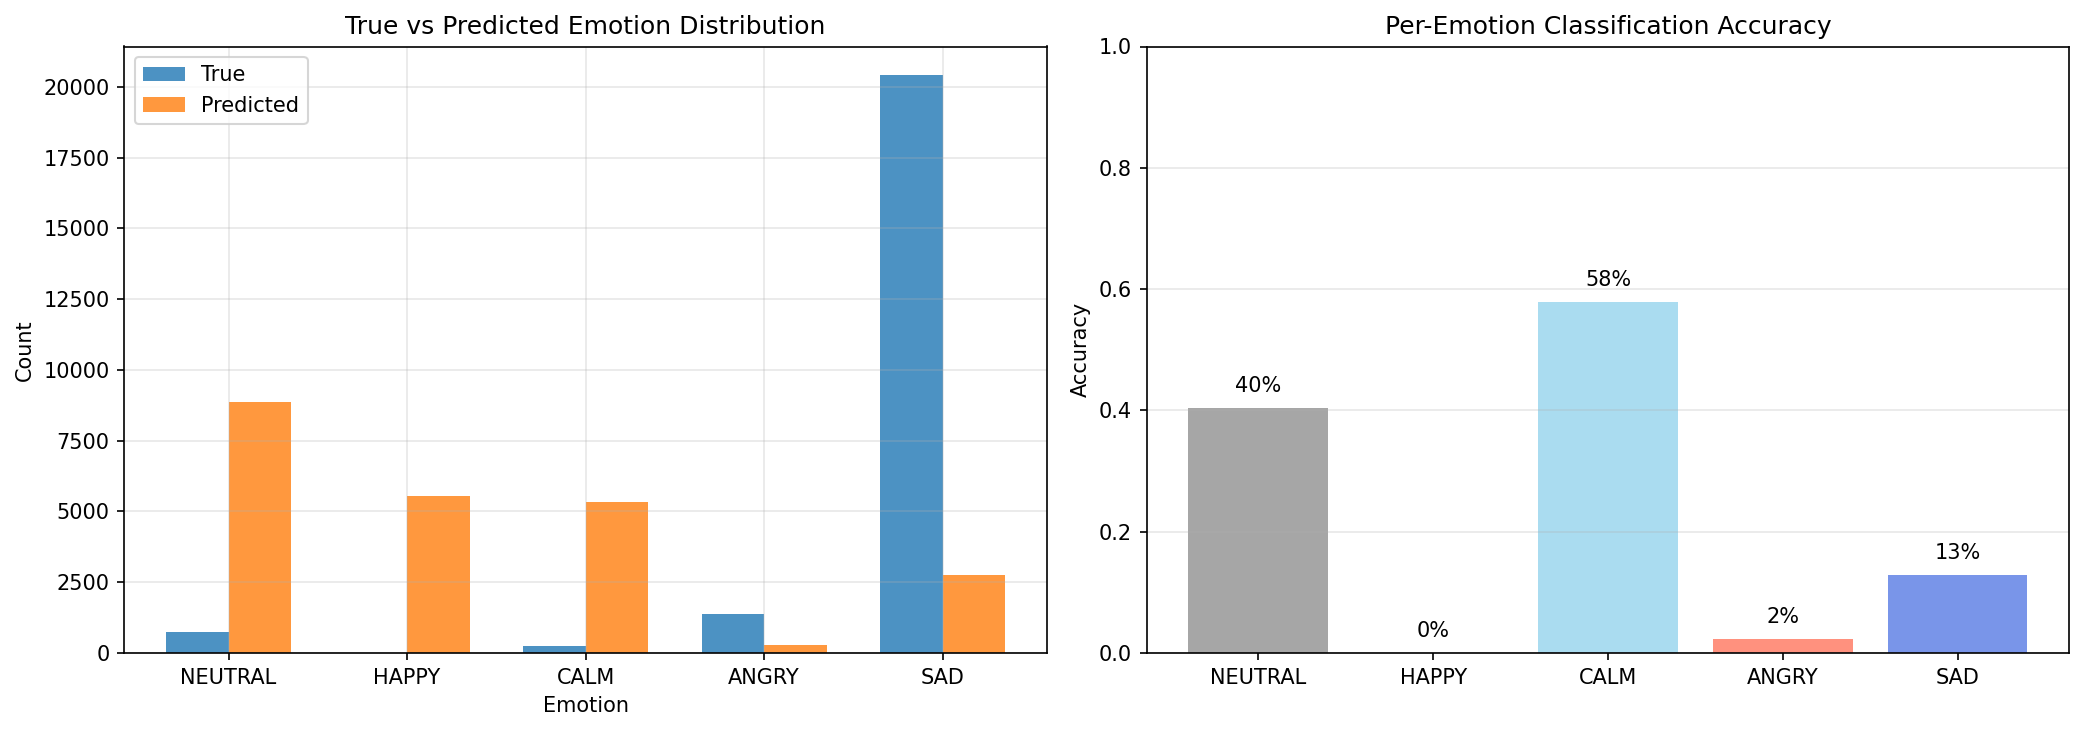

In [16]:

print("\nDisplaying True vs Predicted Emotion Distributions:")
display(Image(filename='emotion_dist_lstm.png'))



Displaying Valence-Arousal Scatter Plot:


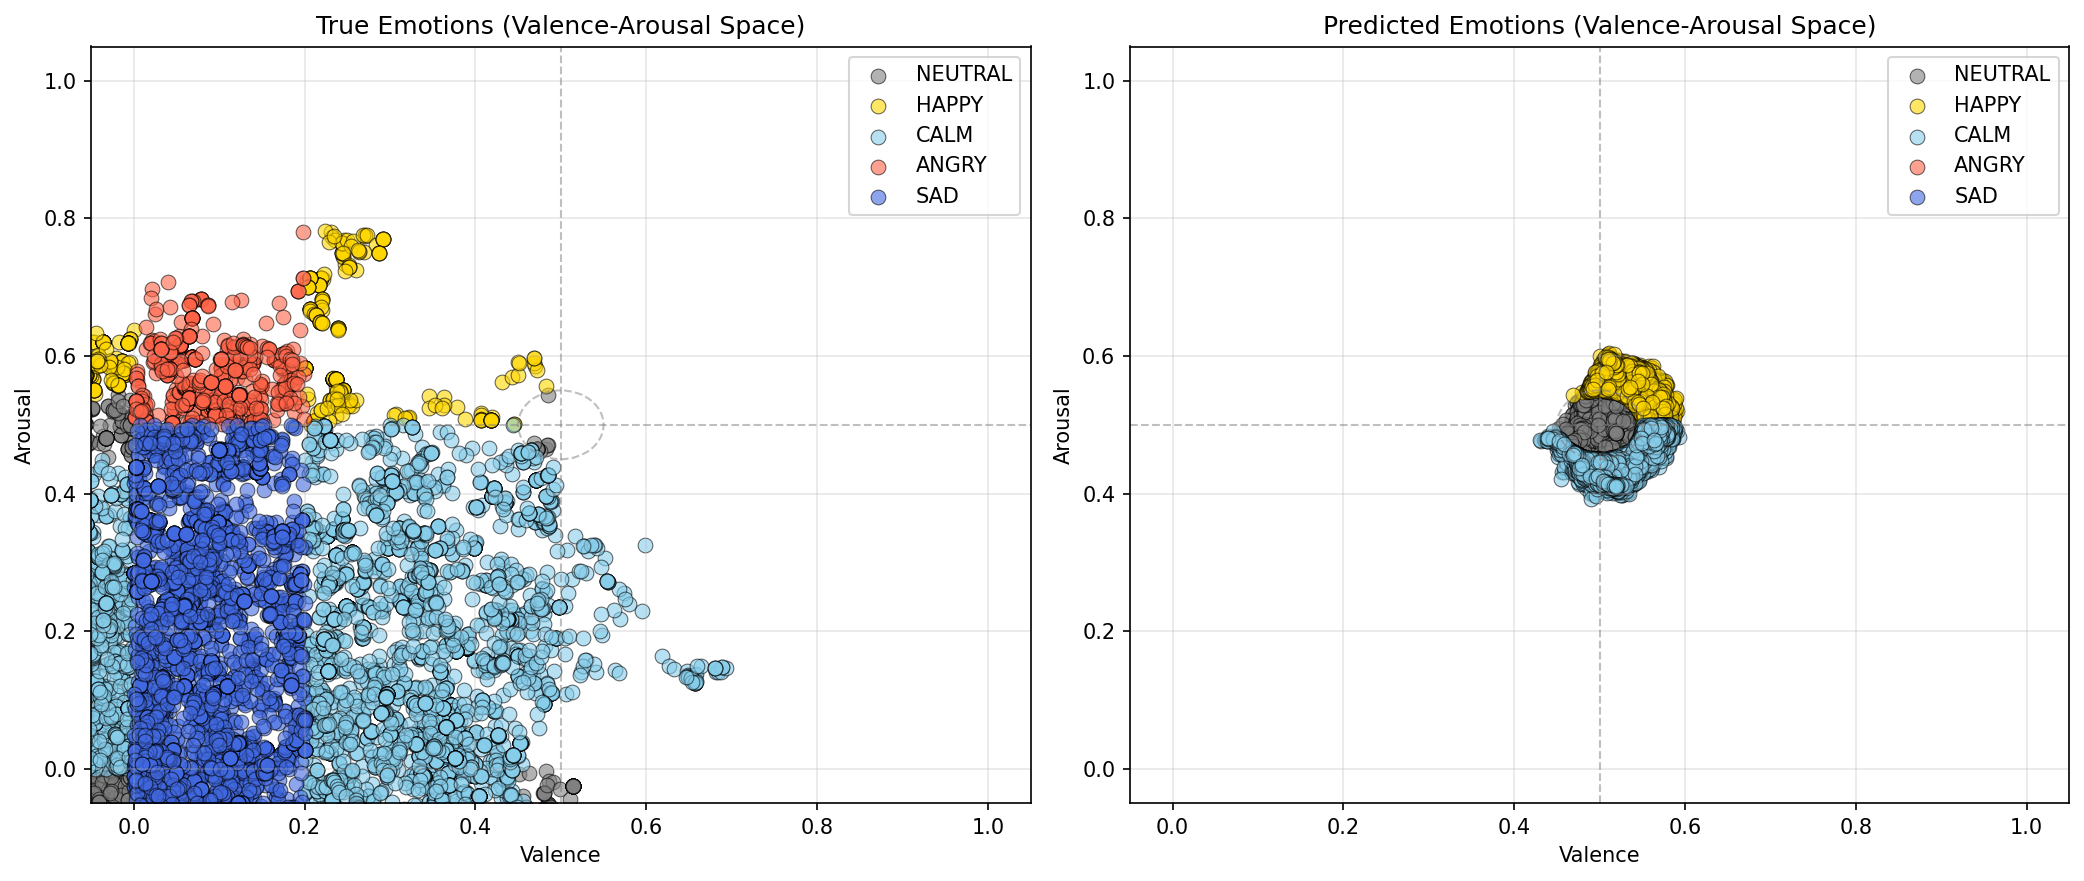

In [26]:

print("\nDisplaying Valence-Arousal Scatter Plot:")
display(Image(filename='emotion_scatter_lstm.png'))

In [27]:
results = evaluate_lstm_emotions(
    model=model,
    test_mel_specs=test_mel_specs,
    true_valences=test_valences,
    true_arousals=test_arousals,
    output_file='lstm_emotion_results.json'
)

LSTM EMOTION CLASSIFICATION EVALUATION

✓ Loaded 22756 test samples

Making predictions...
  5000/22756
  10000/22756
  15000/22756
  20000/22756
✓ Predictions made

Evaluating emotion classification...

RESULTS

✓ Overall Emotion Classification Accuracy: 27.5%

Per-Emotion Accuracy:
  NEUTRAL   :  40.5% (n=  744)
  HAPPY     :  73.0% (n=  653)
  CALM      :  39.0% (n=14056)
  ANGRY     :   0.0% (n=  716)
  SAD       :   0.0% (n= 6587)

True Emotion Distribution:
  NEUTRAL   :   744 (  3.3%)
  HAPPY     :   653 (  2.9%)
  CALM      : 14056 ( 61.8%)
  ANGRY     :   716 (  3.1%)
  SAD       :  6587 ( 28.9%)

Predicted Emotion Distribution:
  NEUTRAL   :  8854 ( 38.9%)
  HAPPY     :  5838 ( 25.7%)
  CALM      :  8064 ( 35.4%)
  ANGRY     :     0 (  0.0%)
  SAD       :     0 (  0.0%)

REGRESSION METRICS (Valence & Arousal)

Valence:
  MAE:  0.4567
  RMSE: 0.4973

Arousal:
  MAE:  0.5350
  RMSE: 0.5997

SAVING RESULTS

✓ Saved confusion matrix: emotion_cm_lstm.png
✓ Saved distributions: emo

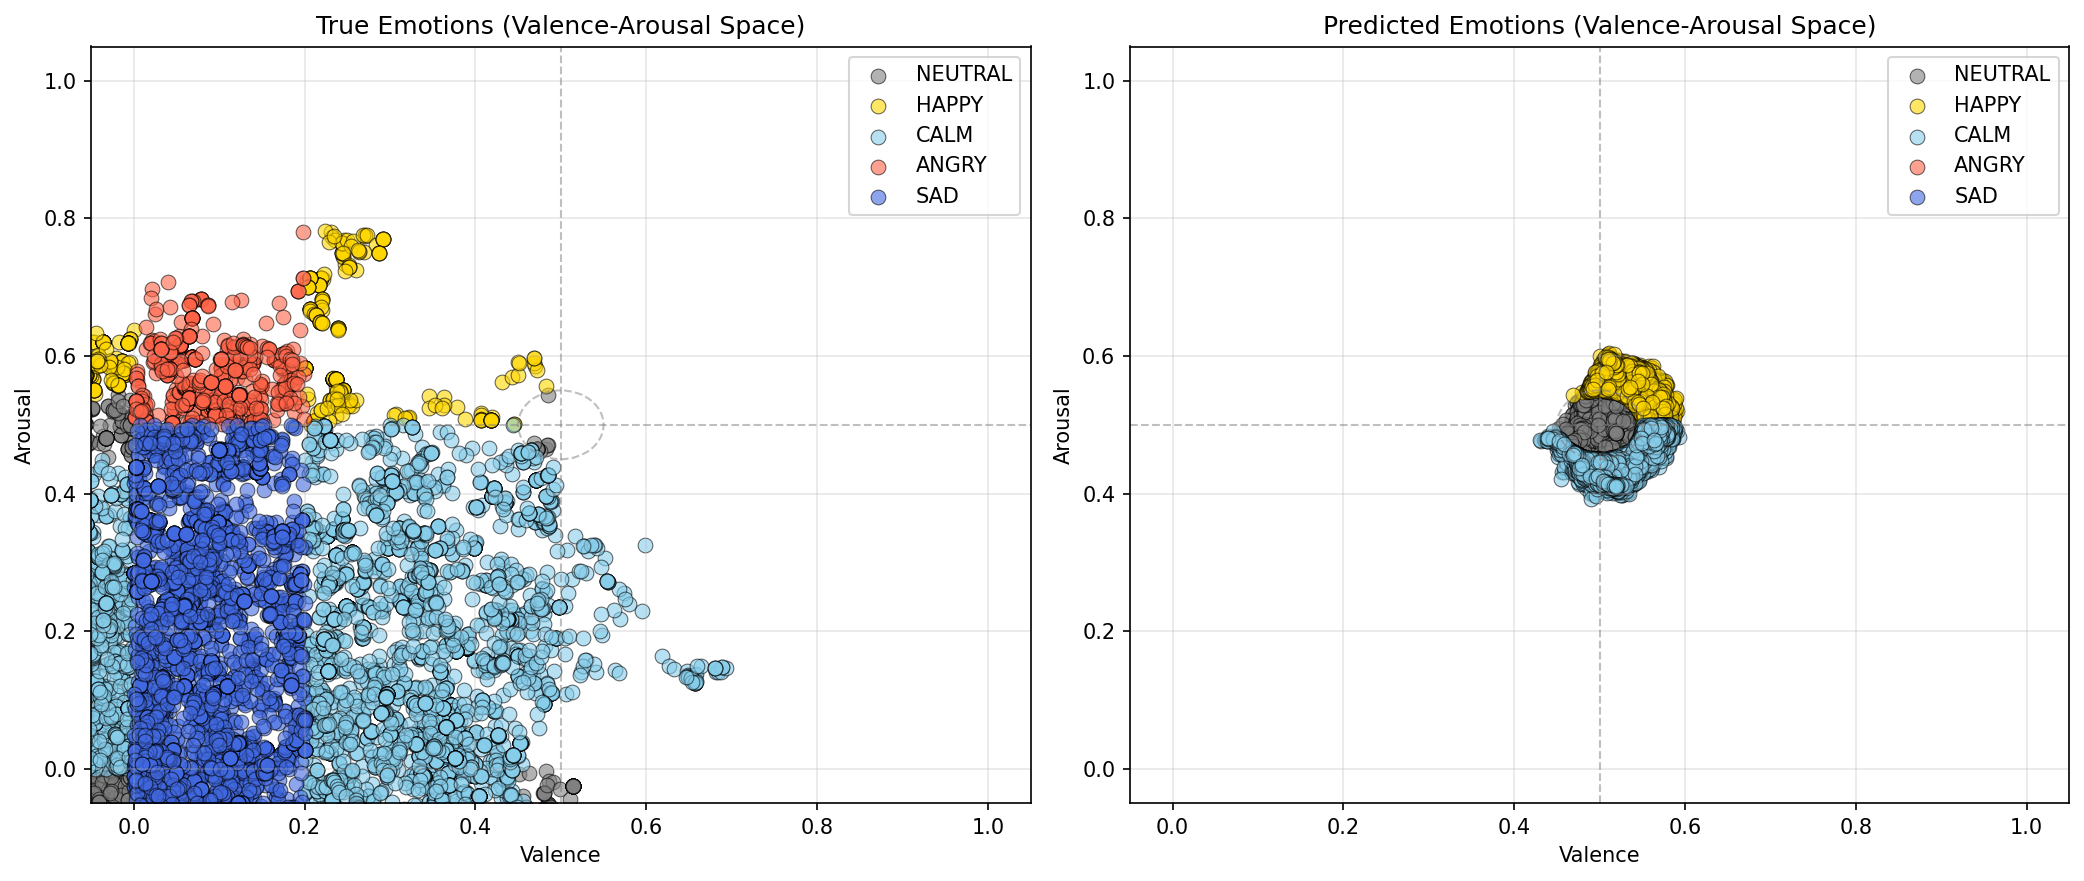

In [28]:
display(Image(filename='emotion_scatter_lstm.png'))

In [24]:
tagger = EmotionTagger()

# True emotions scatter
ax = axes[0]
true_emotions = tagger.tag_batch(true_valences, true_arousals)

for emotion in tagger.emotion_labels:
    mask = true_emotions == emotion
    ax.scatter(
        true_valences[mask],
        true_arousals[mask],
        label=emotion,
        color=tagger.emotion_colors[emotion],
        alpha=0.6,
        s=50,
        edgecolors='black',
        linewidth=0.5
    )

# Linie podziału dla zakresu [-1,1]
ax.axvline(x=0.0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(y=0.0, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Neutral zone wokół środka (0,0)
from matplotlib.patches import Circle
neutral_r = tagger.thresholds['neutral_radius']
circle = Circle((0.0, 0.0), neutral_r, fill=False,
                linestyle='--', color='gray', alpha=0.5)
ax.add_patch(circle)

ax.set_xlabel('Valence')
ax.set_ylabel('Arousal')
ax.set_title('True Emotions (Valence-Arousal Space)')
ax.set_xlim([-1.05, 1.05])
ax.set_ylim([-1.05, 1.05])
ax.legend()
ax.grid(alpha=0.3)

NameError: name 'true_valences' is not defined

Liczba próbek: 22756
Zakres valence: -0.57625 -> 0.6936249999999999
Zakres arousal: -0.7112857142857143 -> 0.7986666666666666


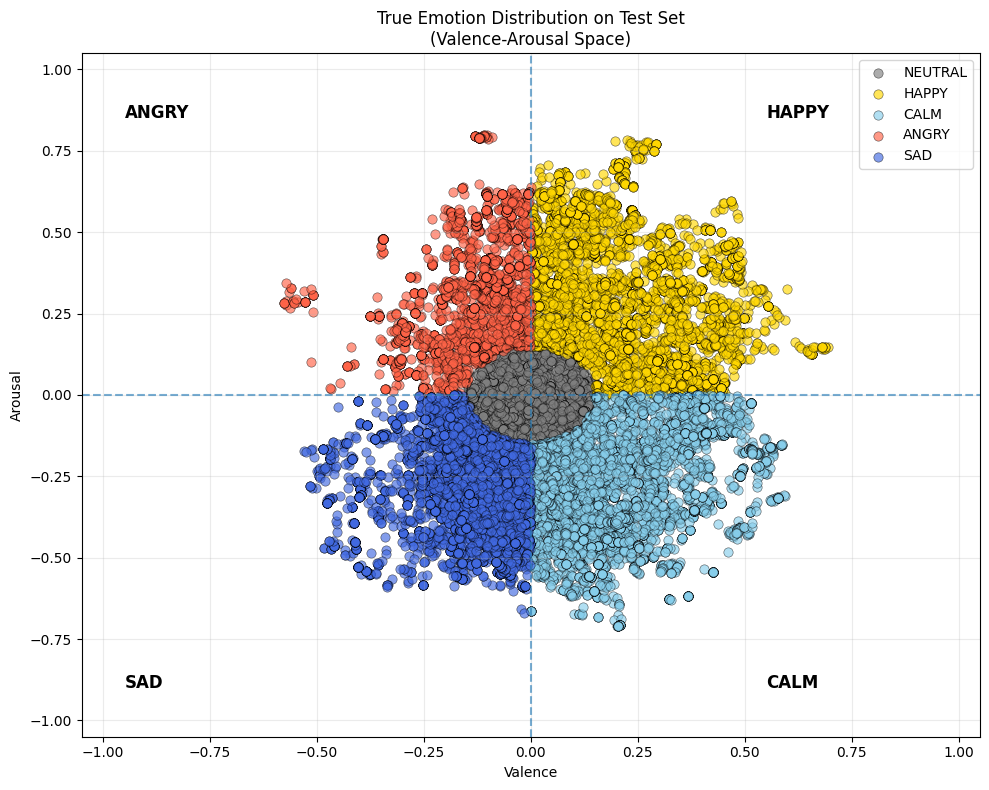

Zapisano: true_emotion_scatter_fixed.png


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# =====================================================
# 1. WCZYTANIE DANYCH
# =====================================================
# Zakładam że masz już:
# test_valences
# test_arousals
#
# Jeśli z pliku npy:
# test_valences = np.load("test_valences.npy")
# test_arousals = np.load("test_arousals.npy")

true_valences = np.array(test_valences)
true_arousals = np.array(test_arousals)

print("Liczba próbek:", len(true_valences))
print("Zakres valence:", true_valences.min(), "->", true_valences.max())
print("Zakres arousal:", true_arousals.min(), "->", true_arousals.max())

# =====================================================
# 2. MAPOWANIE EMOCJI dla zakresu [-1,1]
# =====================================================

def tag_emotion(valence, arousal, neutral_radius=0.15):

    # strefa neutralna wokół (0,0)
    dist = np.sqrt(valence**2 + arousal**2)
    if dist < neutral_radius:
        return "NEUTRAL"

    if valence >= 0 and arousal >= 0:
        return "HAPPY"     # pozytywna + aktywna
    elif valence >= 0 and arousal < 0:
        return "CALM"      # pozytywna + spokojna
    elif valence < 0 and arousal >= 0:
        return "ANGRY"     # negatywna + aktywna
    else:
        return "SAD"       # negatywna + pasywna


true_emotions = np.array([
    tag_emotion(v, a)
    for v, a in zip(true_valences, true_arousals)
])

# =====================================================
# 3. KOLORY
# =====================================================

emotion_colors = {
    'NEUTRAL': '#808080',
    'HAPPY':   '#FFD700',
    'CALM':    '#87CEEB',
    'ANGRY':   '#FF6347',
    'SAD':     '#4169E1'
}

emotion_order = ['NEUTRAL', 'HAPPY', 'CALM', 'ANGRY', 'SAD']

# =====================================================
# 4. WYKRES
# =====================================================

plt.figure(figsize=(10, 8))

for emotion in emotion_order:
    mask = true_emotions == emotion

    plt.scatter(
        true_valences[mask],
        true_arousals[mask],
        label=emotion,
        color=emotion_colors[emotion],
        alpha=0.65,
        s=45,
        edgecolors='black',
        linewidth=0.4
    )

# Linie podziału
plt.axvline(0, linestyle='--', alpha=0.6)
plt.axhline(0, linestyle='--', alpha=0.6)

# Neutral zone
circle = Circle((0, 0), 0.15, fill=False, linestyle='--', alpha=0.6)
plt.gca().add_patch(circle)

# Opisy ćwiartek
plt.text(0.55, 0.85, "HAPPY", fontsize=12, weight='bold')
plt.text(0.55, -0.90, "CALM", fontsize=12, weight='bold')
plt.text(-0.95, 0.85, "ANGRY", fontsize=12, weight='bold')
plt.text(-0.95, -0.90, "SAD", fontsize=12, weight='bold')

# Ustawienia
plt.xlim(-1.05, 1.05)
plt.ylim(-1.05, 1.05)

plt.xlabel("Valence")
plt.ylabel("Arousal")
plt.title("True Emotion Distribution on Test Set\n(Valence-Arousal Space)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

# zapis
plt.savefig("true_emotion_scatter_fixed.png", dpi=200)
plt.show()

print("Zapisano: true_emotion_scatter_fixed.png")

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =====================================================
# ZAŁOŻENIA
# =====================================================
# Masz już w pamięci:
# pred_valences   -> predykcje modelu w zakresie [0,1]
# pred_arousals   -> predykcje modelu w zakresie [0,1]
# test_valences   -> ground truth w zakresie [-1,1]
# test_arousals   -> ground truth w zakresie [-1,1]

true_valences = np.array(test_valences)
true_arousals = np.array(test_arousals)

pred_valences = np.array(pred_valences)
pred_arousals = np.array(pred_arousals)

# =====================================================
# 1. PRZESUNIĘCIE PREDYKCJI
# z [0,1] -> [-0.5,0.5]
# środek 0.5 -> 0.0
# =====================================================

pred_val_shift = pred_valences - 0.5
pred_arou_shift = pred_arousals - 0.5

print("Zakres pred valence:", pred_val_shift.min(), "->", pred_val_shift.max())
print("Zakres pred arousal:", pred_arou_shift.min(), "->", pred_arou_shift.max())

# =====================================================
# 2. TAGOWANIE EMOCJI
# =====================================================

def tag_emotion(v, a, neutral_radius=0.15):
    dist = np.sqrt(v**2 + a**2)

    if dist < neutral_radius:
        return "NEUTRAL"

    if v >= 0 and a >= 0:
        return "HAPPY"
    elif v >= 0 and a < 0:
        return "CALM"
    elif v < 0 and a >= 0:
        return "ANGRY"
    else:
        return "SAD"

# true labels
true_emotions = np.array([
    tag_emotion(v, a)
    for v, a in zip(true_valences, true_arousals)
])

# predicted labels
pred_emotions = np.array([
    tag_emotion(v, a)
    for v, a in zip(pred_val_shift, pred_arou_shift)
])

# =====================================================
# 3. ACCURACY
# =====================================================

accuracy = accuracy_score(true_emotions, pred_emotions)

print("="*60)
print("EMOTION CLASSIFICATION RESULTS")
print("="*60)
print(f"Overall Accuracy: {accuracy:.2%}")
print()

print(classification_report(
    true_emotions,
    pred_emotions,
    digits=3,
    zero_division=0
))

# =====================================================
# 4. WYKRES PREDYKCJI
# =====================================================

emotion_colors = {
    'NEUTRAL': '#808080',
    'HAPPY':   '#FFD700',
    'CALM':    '#87CEEB',
    'ANGRY':   '#FF6347',
    'SAD':     '#4169E1'
}

emotion_order = ['NEUTRAL', 'HAPPY', 'CALM', 'ANGRY', 'SAD']

plt.figure(figsize=(10,8))

for emotion in emotion_order:
    mask = pred_emotions == emotion

    plt.scatter(
        pred_val_shift[mask],
        pred_arou_shift[mask],
        color=emotion_colors[emotion],
        label=emotion,
        alpha=0.65,
        s=45,
        edgecolors='black',
        linewidth=0.4
    )

# osie
plt.axvline(0, linestyle='--', alpha=0.6)
plt.axhline(0, linestyle='--', alpha=0.6)

# neutral zone
circle = Circle((0,0), 0.15, fill=False, linestyle='--', alpha=0.6)
plt.gca().add_patch(circle)

# opisy
plt.text(0.28, 0.42, "HAPPY", fontsize=12, weight='bold')
plt.text(0.28, -0.47, "CALM", fontsize=12, weight='bold')
plt.text(-0.48, 0.42, "ANGRY", fontsize=12, weight='bold')
plt.text(-0.48, -0.47, "SAD", fontsize=12, weight='bold')

plt.xlim(-0.55, 0.55)
plt.ylim(-0.55, 0.55)

plt.xlabel("Predicted Valence (shifted)")
plt.ylabel("Predicted Arousal (shifted)")
plt.title(f"Predicted Emotion Distribution\nAccuracy = {accuracy:.2%}")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

plt.savefig("predicted_emotion_scatter_shifted.png", dpi=200)
plt.show()

print("Saved: predicted_emotion_scatter_shifted.png")


NameError: name 'pred_valences' is not defined

Prediction vectors created:
(22756,)
(22756,)
RESULTS
Accuracy: 13.09 %

              precision    recall  f1-score   support

       ANGRY      0.000     0.000     0.000      2658
        CALM      0.000     0.000     0.000      6263
       HAPPY      0.000     0.000     0.000      5641
     NEUTRAL      0.131     1.000     0.231      2978
         SAD      0.000     0.000     0.000      5216

    accuracy                          0.131     22756
   macro avg      0.026     0.200     0.046     22756
weighted avg      0.017     0.131     0.030     22756



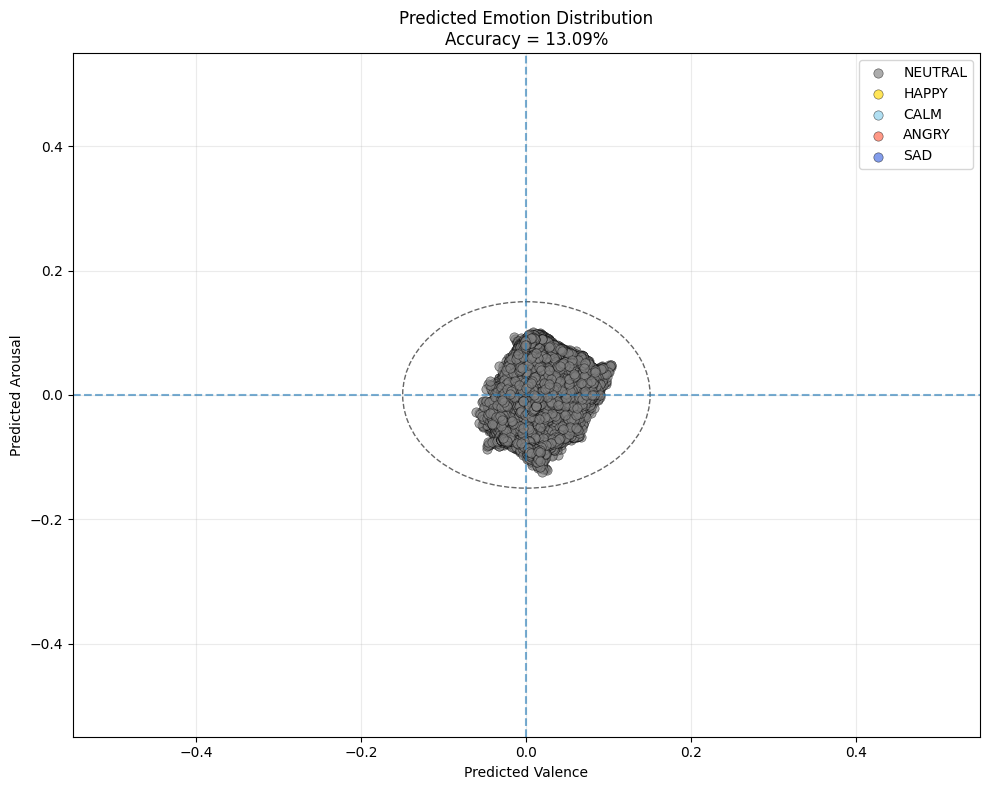

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from sklearn.metrics import accuracy_score, classification_report

# =====================================================
# 0. ZRÓB PREDYKCJE MODELU
# =====================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

pred_valences = []
pred_arousals = []

with torch.no_grad():
    for mel_spec in test_mel_specs:

        x = torch.FloatTensor(mel_spec).unsqueeze(0).to(device)

        output = model(x)   # shape (1,2)

        pred_valences.append(output[0,0].cpu().item())
        pred_arousals.append(output[0,1].cpu().item())

pred_valences = np.array(pred_valences)
pred_arousals = np.array(pred_arousals)

print("Prediction vectors created:")
print(pred_valences.shape)
print(pred_arousals.shape)

# =====================================================
# 1. jeśli model dawał sigmoid/logits
# =====================================================
# jeśli wcześniej używałeś expit(sigmoid), odkomentuj:

from scipy.special import expit

pred_valences = expit(pred_valences)
pred_arousals = expit(pred_arousals)

# =====================================================
# 2. SHIFT [0,1] -> [-0.5,0.5]
# =====================================================

pred_val_shift = (pred_valences - 0.5)
pred_arou_shift = (pred_arousals - 0.5)

# =====================================================
# 3. TRUE DATA
# =====================================================

true_valences = np.array(test_valences)
true_arousals = np.array(test_arousals)

# =====================================================
# 4. EMOTION TAGGING
# =====================================================

def tag_emotion(v, a, neutral_radius=0.15):

    dist = np.sqrt(v**2 + a**2)

    if dist < neutral_radius:
        return "NEUTRAL"

    if v >= 0 and a >= 0:
        return "HAPPY"
    elif v >= 0 and a < 0:
        return "CALM"
    elif v < 0 and a >= 0:
        return "ANGRY"
    else:
        return "SAD"

true_emotions = np.array([
    tag_emotion(v, a)
    for v, a in zip(true_valences, true_arousals)
])

pred_emotions = np.array([
    tag_emotion(v, a)
    for v, a in zip(pred_val_shift, pred_arou_shift)
])

# =====================================================
# 5. ACCURACY
# =====================================================

acc = accuracy_score(true_emotions, pred_emotions)

print("="*60)
print("RESULTS")
print("="*60)
print("Accuracy:", round(acc*100,2), "%")
print()

print(classification_report(
    true_emotions,
    pred_emotions,
    digits=3,
    zero_division=0
))

# =====================================================
# 6. PLOT
# =====================================================

emotion_colors = {
    'NEUTRAL': '#808080',
    'HAPPY':   '#FFD700',
    'CALM':    '#87CEEB',
    'ANGRY':   '#FF6347',
    'SAD':     '#4169E1'
}

order = ['NEUTRAL','HAPPY','CALM','ANGRY','SAD']

plt.figure(figsize=(10,8))

for emotion in order:

    mask = pred_emotions == emotion

    plt.scatter(
        pred_val_shift[mask],
        pred_arou_shift[mask],
        label=emotion,
        color=emotion_colors[emotion],
        alpha=0.65,
        s=45,
        edgecolors='black',
        linewidth=0.4
    )

plt.axvline(0, linestyle='--', alpha=0.6)
plt.axhline(0, linestyle='--', alpha=0.6)

circle = Circle((0,0), 0.15, fill=False, linestyle='--', alpha=0.6)
plt.gca().add_patch(circle)

plt.xlim(-0.55,0.55)
plt.ylim(-0.55,0.55)

plt.xlabel("Predicted Valence")
plt.ylabel("Predicted Arousal")
plt.title(f"Predicted Emotion Distribution\nAccuracy = {acc:.2%}")

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

plt.savefig("predicted_emotions_shifted.png", dpi=200)
plt.show()

RESULTS
Accuracy: 46.09 %

              precision    recall  f1-score   support

       ANGRY      0.303     0.250     0.274      2658
        CALM      0.509     0.408     0.453      6263
       HAPPY      0.572     0.695     0.627      5641
     NEUTRAL      0.172     0.163     0.167      2978
         SAD      0.488     0.549     0.517      5216

    accuracy                          0.461     22756
   macro avg      0.409     0.413     0.408     22756
weighted avg      0.452     0.461     0.453     22756



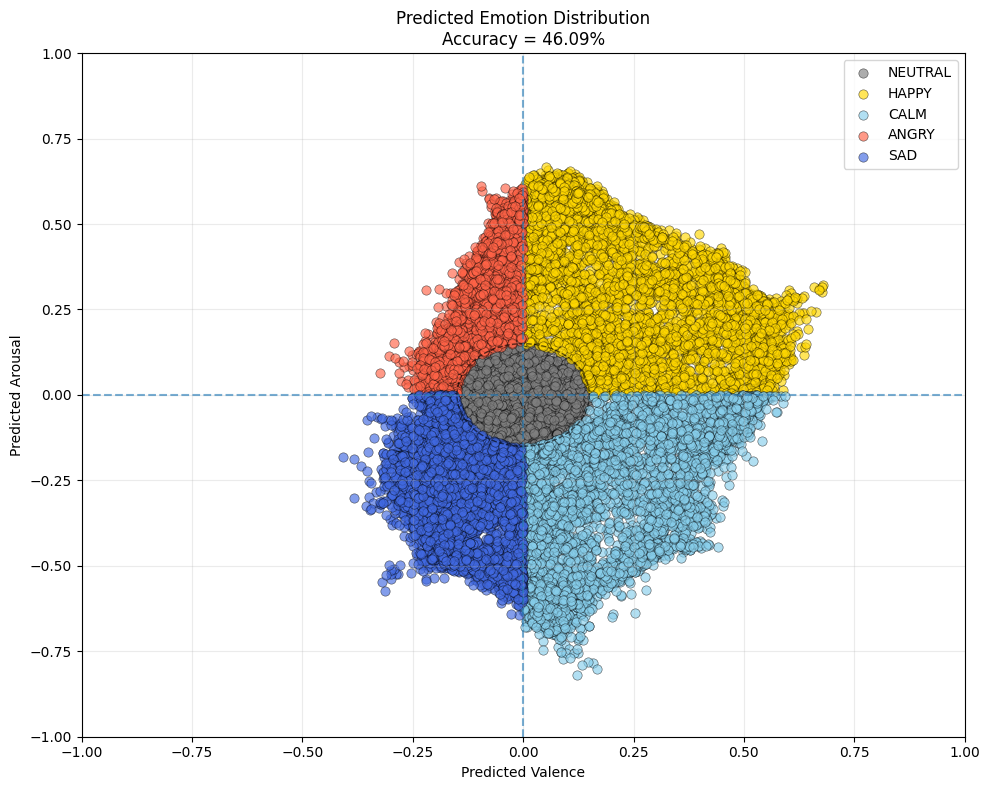

In [43]:
pred_val_shift = pred_val_shift / 0.9
pred_arou_shift = pred_arou_shift / 0.9

# =====================================================
# 3. TRUE DATA
# =====================================================

# true_valences = np.array(test_valences)
# true_arousals = np.array(test_arousals)

# =====================================================
# 4. EMOTION TAGGING
# =====================================================

def tag_emotion(v, a, neutral_radius=0.15):

    dist = np.sqrt(v**2 + a**2)

    if dist < neutral_radius:
        return "NEUTRAL"

    if v >= 0 and a >= 0:
        return "HAPPY"
    elif v >= 0 and a < 0:
        return "CALM"
    elif v < 0 and a >= 0:
        return "ANGRY"
    else:
        return "SAD"

true_emotions = np.array([
    tag_emotion(v, a)
    for v, a in zip(true_valences, true_arousals)
])

pred_emotions = np.array([
    tag_emotion(v, a)
    for v, a in zip(pred_val_shift, pred_arou_shift)
])

# =====================================================
# 5. ACCURACY
# =====================================================

acc = accuracy_score(true_emotions, pred_emotions)

print("="*60)
print("RESULTS")
print("="*60)
print("Accuracy:", round(acc*100,2), "%")
print()

print(classification_report(
    true_emotions,
    pred_emotions,
    digits=3,
    zero_division=0
))

# =====================================================
# 6. PLOT
# =====================================================

emotion_colors = {
    'NEUTRAL': '#808080',
    'HAPPY':   '#FFD700',
    'CALM':    '#87CEEB',
    'ANGRY':   '#FF6347',
    'SAD':     '#4169E1'
}

order = ['NEUTRAL','HAPPY','CALM','ANGRY','SAD']

plt.figure(figsize=(10,8))

for emotion in order:

    mask = pred_emotions == emotion

    plt.scatter(
        pred_val_shift[mask],
        pred_arou_shift[mask],
        label=emotion,
        color=emotion_colors[emotion],
        alpha=0.65,
        s=45,
        edgecolors='black',
        linewidth=0.4
    )

plt.axvline(0, linestyle='--', alpha=0.6)
plt.axhline(0, linestyle='--', alpha=0.6)

circle = Circle((0,0), 0.15, fill=False, linestyle='--', alpha=0.6)
plt.gca().add_patch(circle)

plt.xlim(-1,1)
plt.ylim(-1,1)

plt.xlabel("Predicted Valence")
plt.ylabel("Predicted Arousal")
plt.title(f"Predicted Emotion Distribution\nAccuracy = {acc:.2%}")

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

plt.savefig("predicted_emotions_shifted.png", dpi=200)
plt.show()